In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

ImportError: cannot import name 'classification' from 'sklearn.metrics' (C:\Users\human\anaconda3\envs\ai_new\Lib\site-packages\sklearn\metrics\__init__.py)

In [12]:
iris = load_iris()
X = iris.data
y = iris.target

class_names = iris.target_names

X_train,X_test,y_train,y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    Stratify=y
)

In [14]:
svm_clf = make_pipeline(
    StandardScaler(),
    SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
)
svm_clf.fit(X_train, y_train)

knn_clf = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)
knn_clf.fit(X_train, y_train)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_clf.fit(X_train, y_train)

# 3개의 모델을 soft voting 방식으로 결합한 VotingClassifier이다.
voting_clf = VotingClassifier(
    estimators=[('svm', svm_clf),('knn', knn_clf),('rf',rf_clf)],
    voting='soft',
    weights=[1,1,2]
)
voting_clf.fit(X_train, y_train)

,estimators,"[('svm', ...), ('knn', ...), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'


In [18]:
svm_pred = svm_clf.predict(X_test)
knn_pred = knn_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)

voting_pred = voting_clf.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)
knn_acc = accuracy_score(y_test, knn_pred)
rf_acc = accuracy_score(y_test, rf_pred)

voting_acc = accuracy_score(y_test, voting_pred)

print(f"SVM 정확도: {svm_acc}")
print(f"KNN 정확도: {knn_acc}")
print(f"Random Forest 정확도: {rf_acc}")
print(f"Voting Classifier 정확도: {voting_acc}")

SVM 정확도: 0.9666666666666667
KNN 정확도: 0.9333333333333333
Random Forest 정확도: 0.9
Voting Classifier 정확도: 0.9


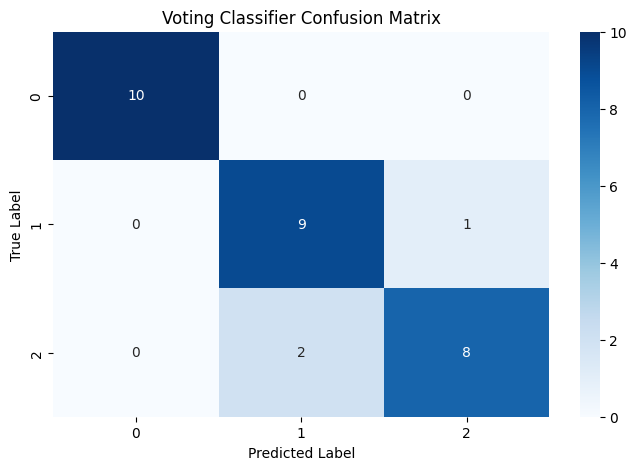

In [26]:
cm = confusion_matrix(y_test, voting_pred)

plt.figure(figsize=(8,5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues'
) 

plt.title('Voting Classifier Confusion Matrix') 
plt.xlabel('Predicted Label') 
plt.ylabel('True Label')
plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_440\2308706041.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x='class', y='f1', palette='viridis')


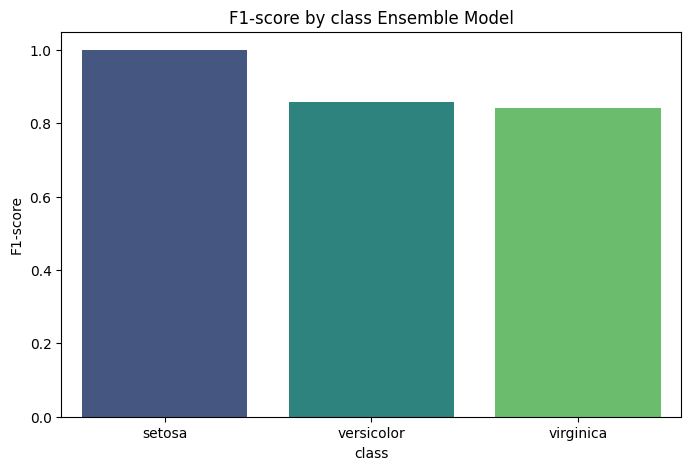

In [25]:
report = classification_report(
    y_test, voting_pred,
    target_names=class_names,
    output_dict=True
)

f1_score = [report[c]['f1-score'] for c in class_names]

df_f1 = pd.DataFrame({'class': class_names, 'f1':f1_score})

plt.figure(figsize=(8,5))
sns.barplot(data=df_f1, x='class', y='f1', palette='viridis')
plt.title('F1-score by class Ensemble Model')
plt.ylabel('F1-score')
plt.ylim(0, 1.05)
plt.show()

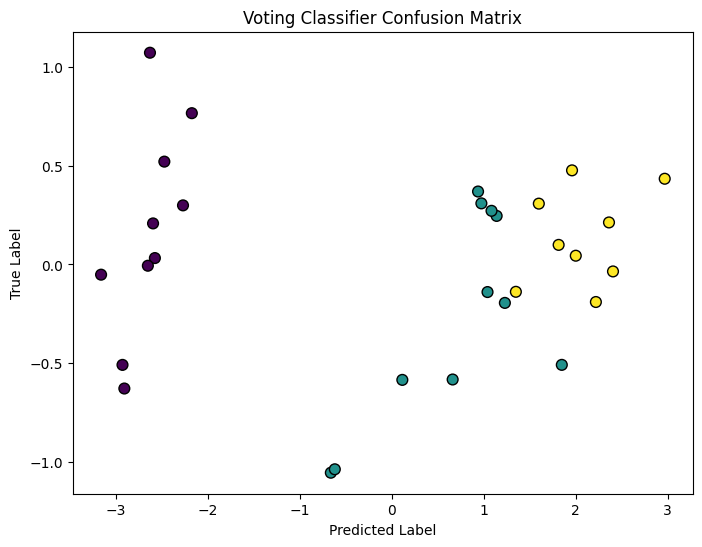

In [29]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=voting_pred,
    cmap='viridis',
    s=60,
    edgecolors='k'
)

plt.title('Voting Classifier Confusion Matrix') 
plt.xlabel('Predicted Label') 
plt.ylabel('True Label')
plt.show()

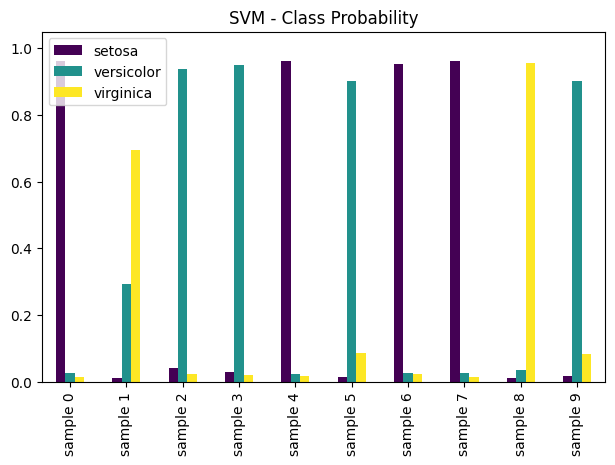

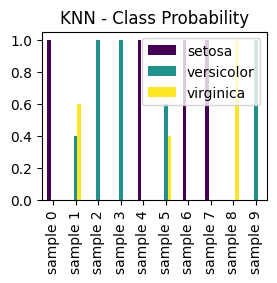

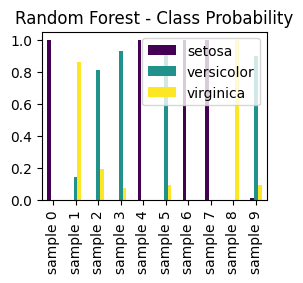

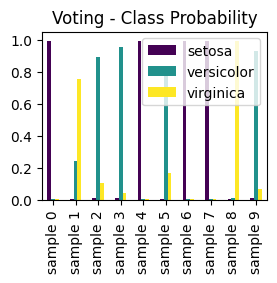

In [32]:
idx = np.arange(10)
X_sample = X_test[idx]
y_sample = y_test[idx]

proba_svm = svm_clf.predict_proba(X_sample)
proba_knn = knn_clf.predict_proba(X_sample)
proba_rf = rf_clf.predict_proba(X_sample)
proba_vote = voting_clf.predict_proba(X_sample)     # voting Classifier(soft voting)의 예측 확률

model_names = ["SVM","KNN","Random Forest","Voting"]
proba_list = [proba_svm, proba_knn, proba_rf, proba_vote]

plt.figure(figsize=(16,10))

for i, (model_name,proba) in enumerate(zip(model_names, proba_list)):
    plt.subplot(2,2,i+1)
    df_prob = pd.DataFrame(proba, columns=class_names)
    df_prob.index = [f'sample {i}' for i in range(len(df_prob))]

    df_prob.plot(kind='bar', ax=plt.gca(), colormap='viridis')
    plt.title(f'{model_name} - Class Probability')
    plt.ylim(0,1.05)
    plt.show()